# InSilicoICH: Part 3. Running Studies

This notebook combines the pieces from [01_phantoms.ipynb](01_phantoms.ipynb) and [02_scanners.ipynb](02_scanners.ipynb) into the full pipeline, checkout those notebooks for more in depth coverage of each

This notebook introduces the `ICHStudy` class, which is an extension of the VITools Study class used to run studies with the phantoms and scanners defined in the previous notebooks. ICHStudy is a subclass of the VITools Study class, which provides additional functionality for adding intracranial hemorrhage (ICH) phantoms, metadata and measurements to the study. It also includes methods for running the study and generating reports.

In [ ]:
from insilicoICH.study import ICHStudy
ICHStudy?

In [ ]:
ICHStudy.generate_from_distributions?

Signature:
ICHStudy.generate_from_distributions(
    phantoms: List[str],
    study_count: int = 1,
    subtype: List[Optional[str]] = [None, 'IPH', 'SDH', 'EDH', 'IVH', 'SAH'],
    fracture_length: List[int] = [0, 200],
    lesion_volume: Union[Dict, str, pathlib._local.Path] = None,
    lesion_attenuation: Union[Dict, str, pathlib._local.Path] = None,
    edema: List[int] = [0, 15],
    mass_effect: list[bool | float] = [0.1, 0.9],
    texture_contrast: List[float] = [0, 3],
    texture_scale: List[float] = [8, 64],
    complexity: List[int] = [1, 4],
    smoothness: List[float] = [0.1, 0.4],
    irregularity: List[float] = [0.1, 0.4],
    eccentricity: List[float] = [0.4, 0.8],
    add_augmentation: bool = True,
    **kwargs,
) -> pandas.core.frame.DataFrame
Docstring: Generates a DataFrame of study parameters by sampling from distributions.
File:      /scratch/brandon.nelson/InSilicoICH/src/insilicoICH/study.py
Type:      method

In [ ]:
from VITools import get_available_phantoms
get_available_phantoms()

{'Water Phantom': VITools.examples.WaterPhantom,
 '0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=9.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsi

In [ ]:
lesion_volume = dict(
    IPH=[0.2, 10],
    SDH=[0.2, 10],
    EDH=[0.2, 10],
    IVH=[1, 20],
    SAH=[1, 15],
    Fracture=[0, 1]) # placeholders for fracture, eventually put in length, thickness etc
lesion_attn = dict(
    IPH=[40, 80],
    SDH=[40, 80],
    EDH=[40, 80],
    IVH=[40, 80],
    SAH=[40, 80],
    Fracture=[0, 1]) # placeholders for fracture, eventually put in length, thickness etc

In [ ]:
import pandas as pd
from VITools import available_scanners

print(available_scanners)
study_list = pd.DataFrame()
study_list = pd.concat([
    study_list,
    ICHStudy.generate_from_distributions(get_available_phantoms(),
                            lesion_volume=lesion_volume,
                            lesion_attenuation=lesion_attn,
                            subtype=['EDH', 'SDH', 'IPH','SAH', 'IVH', 'Fracture'],
                            fracture_length=[150, 250],
                            views=[1000],
                            scanner_model=['Siemens_DefinitionFlash'],
                            study_count=15,
                            seed=88)])
study = ICHStudy(study_list)
study.metadata

['GE_Lightspeed64', 'Scanner_Default', 'GE_Lightspeed16', 'Siemens_DefinitionFlash']
study plan saved to: /scratch/brandon.nelson/InSilicoICH/notebooks/results/study_plan_0000-0014.csv


,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,age,mass_effect,fracture_length,add_augmentation,texture_contrast,texture_scale,complexity,smoothness,irregularity,eccentricity
0,case_0000,10.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,10.50,0.651095,0,True,NaN,NaN,NaN,NaN,NaN,NaN
1,case_0001,2.0 yr UNC Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,2.00,0.351517,191,True,NaN,NaN,NaN,NaN,NaN,NaN
2,case_0002,38.0 yr MIDA Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,38.00,0.641385,181,True,NaN,NaN,NaN,NaN,NaN,NaN
3,case_0003,12.0 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,12.00,0.319382,0,True,NaN,NaN,NaN,NaN,NaN,NaN
4,case_0004,11.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,11.50,0.351525,241,True,NaN,NaN,NaN,NaN,NaN,NaN
5,case_0005,11.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,11.50,0.246471,182,True,NaN,NaN,NaN,NaN,NaN,NaN
6,case_0006,15.75 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,15.75,0.200925,233,True,NaN,NaN,NaN,NaN,NaN,NaN
7,case_0007,11.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,11.50,0.624645,0,True,NaN,NaN,NaN,NaN,NaN,NaN
8,case_0008,9.0 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,9.00,0.351091,0,True,1.333536,50.308850,1.0,0.307308,0.144648,0.664279
9,case_0009,11.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,11.50,0.837484,0,True,2.343754,20.106284,3.0,0.120600,0.232903,0.591067


In [ ]:
study_list[['case_id', 'phantom', 'subtype', 'lesion_volume', 'lesion_attenuation']]

,case_id,phantom,subtype,lesion_volume,lesion_attenuation
0,case_0000,10.5 yr NIHPD Head,SAH,10.898990,67.474747
1,case_0001,2.0 yr UNC Head,SDH,6.733333,46.868687
2,case_0002,38.0 yr MIDA Head,SDH,0.793939,54.545455
3,case_0003,12.0 yr NIHPD Head,SAH,3.969697,74.343434
4,case_0004,11.5 yr NIHPD Head,EDH,5.644444,78.787879
5,case_0005,11.5 yr NIHPD Head,EDH,8.911111,76.767677
6,case_0006,15.75 yr NIHPD Head,EDH,3.070707,63.434343
7,case_0007,11.5 yr NIHPD Head,SAH,14.858586,53.333333
8,case_0008,9.0 yr NIHPD Head,IPH,3.466667,58.181818
9,case_0009,11.5 yr NIHPD Head,IPH,1.090909,64.242424


In [ ]:
study.run_all(parallel=True, overwrite=False)

Running 15 simulation conditions: 0-14
See logs at /scratch/brandon.nelson/InSilicoICH/notebooks/results/logs/VIT-BATCH_12-29-2025_17-29
11617700


Scans completed in parallel:   0%|          | 0/15 [00:00<?, ?it/s]

In [ ]:
study.results['lesion'].unique()

array([nan, 'SAH', 'Fracture', 'SDH', 'EDH', 'IPH', 'IVH'], dtype=object)

In [ ]:
study.metadata['subtype']

0     SAH
1     SDH
2     SDH
3     SAH
4     EDH
5     EDH
6     EDH
7     SAH
8     IPH
9     IPH
10    SAH
11    IPH
12    EDH
13    EDH
14    IVH
Name: subtype, dtype: object

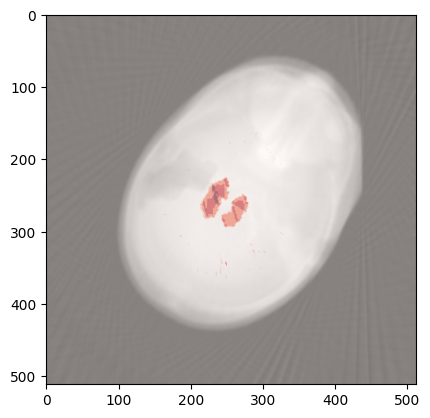

In [ ]:
import matplotlib.pyplot as plt

idx = 14
mask = study.get_masks(idx)
imgs = study.get_images(idx)

plt.imshow(imgs.sum(axis=0), cmap='gray')
plt.imshow(mask.sum(axis=0), cmap='Reds', alpha=0.5)

In [ ]:
from utils import scrollview
scrollview(imgs, (80, 40))

interactive(children=(IntSlider(value=67, description='idx', max=134), Output()), _dom_classes=('widget-intera…

In [ ]:
from insilicoICH.lesion_definition import LesionFactory
phantom = get_available_phantoms()['10.5 yr NIHPD Head']()
lesion = LesionFactory().create('Fracture', boundary=phantom.get_skull_map(), spacings=phantom.spacings, seed=206245)
lesion.generate(fracture_length = 237)
phantom.insert_lesion(lesion)

pseudo-CT images not found; defaulting to otsu segmentation method



        Phantom Class: NIHPD_Head
        Age (years): 10.5
        Shape (voxels): (189, 233, 197)
        Size (mm): (160.65, 198.05, 167.45)
        
Number of lesions: 1
  - Lesion 1: Fracture, Volume: 0.21 mL, Center: (169, 112, 69)
Mass effect strength: 0.0

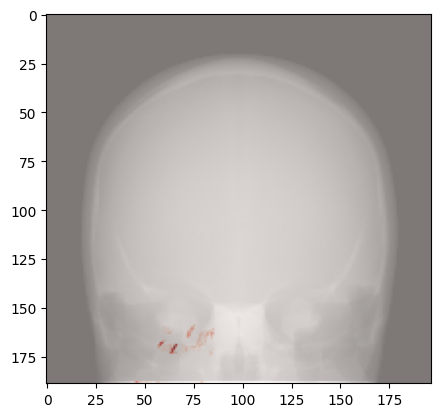

In [ ]:
plt.imshow(phantom.get_CT_number_phantom().sum(axis=1), cmap='gray')
plt.imshow(phantom.lesions[0].mask.sum(axis=1), alpha=0.5, cmap='Reds')


**Fracture appears too high up, out of view, should add some preference for fractures at the sides, more hemorrhage risk and relevant**

In [ ]:
%pip install -q matplotlib ipywidgets


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


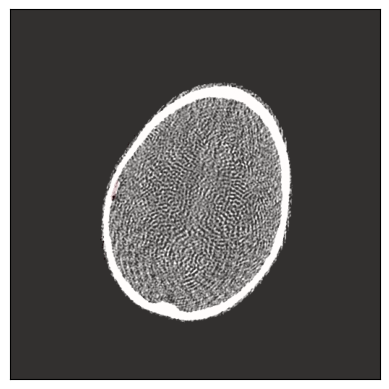

In [ ]:
from utils import ctshow
import matplotlib.pyplot as plt
f, ax = plt.subplots()
idx = len(imgs) // 2
ctshow(imgs[idx], 'brain', fig=f, ax=ax)
ax.imshow(mask[idx], cmap='Reds', alpha=0.2)

In [ ]:
from utils import scrollview
scrollview(imgs, (80, 40))

interactive(children=(IntSlider(value=54, description='idx', max=107), Output()), _dom_classes=('widget-intera…

> [!NOTE]
> The simulation process (`study.run_all` or `study.run_study`) remains exactly the same. The `ICHStudy` class automatically handles the internal logic for partitioning the CSF and generating the appropriate lesion type based on the `subtype` column.